In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import openpyxl
import numpy as np

%matplotlib inline




In [130]:
wtFsC = 'data/FPLC_data/300925_FsC-wt_sph_IEX_cutinase_HiTrap-CM-FF_5ml_GCO_ND_python.csv'
LCC_big = 'data/FPLC_data/171025_LCC-ICCG_bigbatch_IEX_cutinase_HiTrap-CM-FF_5ml_GCO_SHT_ND_python.csv'
LCC_small = 'data/FPLC_data/241025_LCC-ICCG_smallbatch_IEX_cutinase_HiTrap-CM-FF_5ml_GCO_SHT_ND_python.csv'
Double_sph1 = 'data/FPLC_data/011025_FsC-T45P_L182A_sph_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND_python.csv'
Double_sph2 = 'data/FPLC_data/011025_FsC-T45P_L182A_sph_no_sample_app_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND_python.csv'
T45P = 'data/FPLC_data/011025_FsC-T45P_sph_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND_python.csv'
L182A_sph = 'data/FPLC_data/061025_FsC-L182A_sph_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND_python.csv'
L182A_wat = 'data/FPLC_data/061025_FsC-L182A_wat_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND_python.csv'
Double_wat = 'data/FPLC_data/220925_FsC-T45P_L182A_IEX_cutinase_HiTrap-CM-FF_5ml_ND_riktig3.csv'
D16 = 'data/FPLC_data/170226_FsC_D16_sph_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND.csv'
A12 = 'data/FPLC_data/170226_FsC_A12_wat_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND.csv'

In [131]:
# Load the file
df = pd.read_csv(D16, delimiter=';', encoding='utf-8', header = 2)


df
# Print all available sheet names

# Rename columns for clarity
df.rename(columns={
    'ml': 'ml',
    'mAU': 'mAU',
    'ml.1': '%_ml',
    '%': '%',
    'ml.3': 'Injection',
    'ml.4': 'frac_ml',
    'Fraction': 'frac'
}, inplace=True)

df

,ml,mAU,%_ml,%,ml.2,Injection,Injection,Logbook,frac_ml,frac,ml.5,mAU.1,ml.6,mS/cm
0,-25.222282,-0.486342,-25.222282,0,-0.00395,NaN,-25.222282,Method Settings,-0.000422,1.A.1,0,0.041181,-25.222282,0.044735
1,-25.214128,-6.43692,-25.140764,0,NaN,NaN,-25.222191,Equilibration,39.164009,Waste(Frac),0.008154,0.041954,-25.205975,0.045313
2,-25.205976,-6.211413,-25.059246,0,NaN,NaN,-0.029257,Sample Application,39.175743,1.A.2,0.016306,0.042727,-25.189667,0.045761
3,-25.197823,-6.21907,-24.977728,0,NaN,NaN,39.165718,Column Wash,79.174561,1.A.3,0.02446,0.0435,-25.173359,0.045991
4,-25.189669,-6.235345,-24.89621,0,NaN,NaN,89.467949,Elution,89.459625,Waste(Frac),0.032614,0.044273,-25.157053,0.046402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37896,283.757324,14.264977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37897,283.765472,14.25033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37898,283.773621,14.235236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37899,283.781769,14.222329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
# ONLY FOR BIG
# Load the file
df_big = pd.read_csv(A12, delimiter=';', encoding='utf-8', header = 2)

#011025_FsC-T45P_L182A_sph_IEX_cutinase_HiTrap-CM-FF_5ml_faster_GCO_SHT_ND_python

df_big
# Print all available sheet names

# Rename columns for clarity
df_big.rename(columns={
    'ml': 'ml',
    'mAU': 'mAU',
    'ml.1': '%_ml',
    '%': '%',
    'ml.3': 'Injection',
    'ml.4': 'frac_ml',
    'Fraction': 'frac'
}, inplace=True)

df_big


,ml,mAU,%_ml,Injection,ml.2,Logbook,Injection,frac,frac_ml,mAU.1,ml.5,mS/cm,ml.6,%
0,-25.22229,2.799959,0.001429,NaN,-25.222290,Method Settings,-0.000422,1.A.1,0,0.08284,-25.22229,95.427513,-25.22229,0
1,-25.214138,37.058643,NaN,NaN,-25.222198,Equilibration,36.725227,Waste(Frac),0.008152,0.083501,-25.205986,95.183182,-25.140764,0
2,-25.205986,46.451542,NaN,NaN,-0.029242,Sample Application,36.736988,1.A.2,0.016304,0.084162,-25.18968,95.049988,-25.059237,0
3,-25.197832,46.228569,NaN,NaN,36.726929,Column Wash,76.735779,1.A.3,0.024458,0.084822,-25.173376,94.564392,-24.977711,0
4,-25.18968,46.318073,NaN,NaN,87.029160,Elution,87.020798,Waste(Frac),0.03261,0.085483,-25.15707,93.95739,-24.896183,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37601,281.318451,12.221055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37602,281.326599,12.214438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37603,281.334747,12.207889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37604,281.342926,12.202798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
# Convert to numeric, set invalid values as NaN

df['ml'] = pd.to_numeric(df['ml'], errors='coerce')  

df['mAU'] = pd.to_numeric(df['mAU'], errors='coerce')

df['%'] = pd.to_numeric(df['%'], errors='coerce')

df['frac_ml'] = pd.to_numeric(df['frac_ml'], errors='coerce')

# df['frac'] = pd.to_numeric(df['frac'], errors='coerce')
df['frac'] = df['frac'].astype(str)

df['%_ml'] = pd.to_numeric(df['%_ml'], errors='coerce')


df['ml.6'] = pd.to_numeric(df['ml.6'], errors='coerce')

df['mS/cm'] = pd.to_numeric(df['mS/cm'], errors='coerce')


In [ ]:
# Convert to numeric, set invalid values as NaN
# only for big


df_big['ml'] = pd.to_numeric(df_big['ml'], errors='coerce')  

df_big['mAU'] = pd.to_numeric(df_big['mAU'], errors='coerce')

df_big['%'] = pd.to_numeric(df_big['%'], errors='coerce')

df_big['frac_ml'] = pd.to_numeric(df_big['frac_ml'], errors='coerce')
# df['frac'] = pd.to_numeric(df['frac'], errors='coerce')
df_big['frac'] = df_big['frac'].astype(str)

df_big['%_ml'] = pd.to_numeric(df_big['%_ml'], errors='coerce')


df_big['ml.6'] = pd.to_numeric(df_big['ml.6'], errors='coerce')

df_big['mS/cm'] = pd.to_numeric(df_big['mS/cm'], errors='coerce')


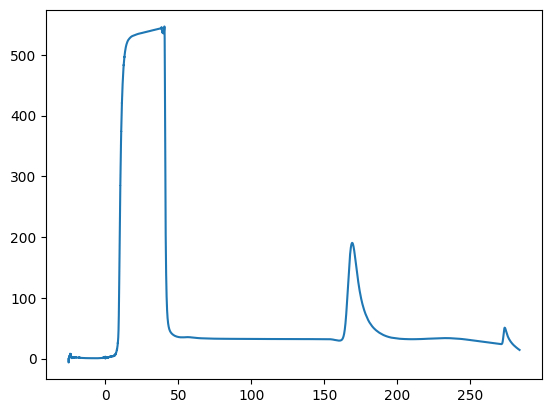

In [135]:
plt.plot(df['ml'], df['mAU'])

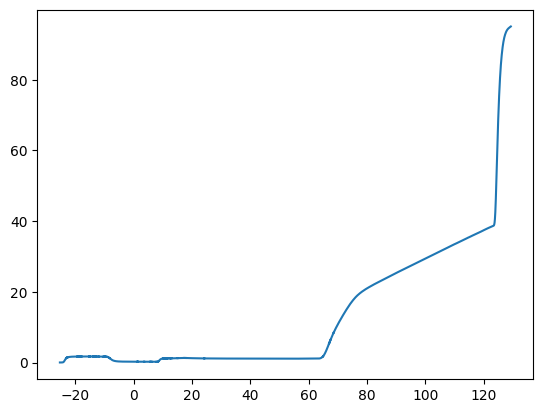

In [136]:
plt.plot(df['ml'],df['mS/cm'])

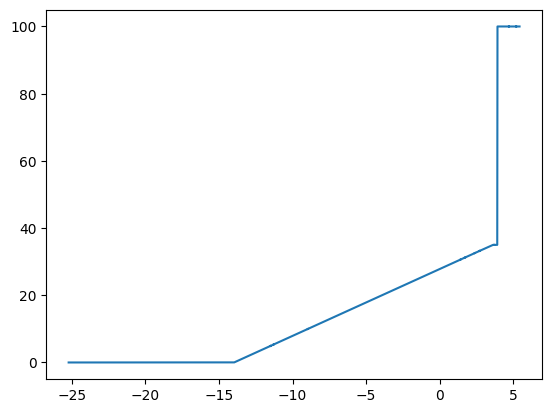

In [137]:
plt.plot(df_big['ml'], df_big['%'])

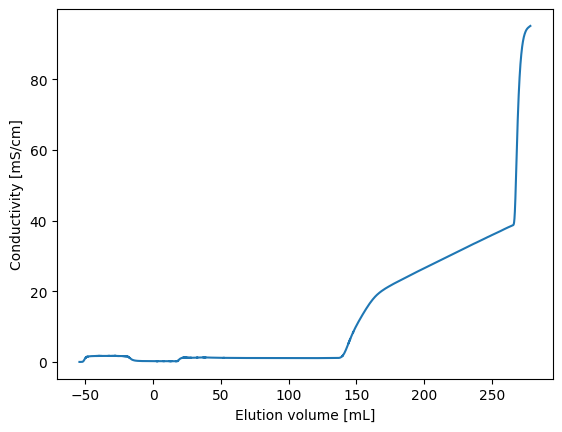

In [138]:
# for some of them, half the conductivity values are missing..? then this shifts the axis so they fit better
plt.plot(df['ml'] * 2.152, df['mS/cm'])
plt.xlabel('Elution volume [mL]')
plt.ylabel('Conductivity [mS/cm]')
plt.show()

In [139]:
 # Find the maximum value of 'ml'
max_ml = df['ml'].max()
max_ml

np.float64(283.789917)

In [140]:
 # Find the maximum value of 'ml'
max_ml = df_big['ml'].max()
max_ml

np.float64(281.351074)

In [141]:
# Add elution buffer to df_big

df_big['%_ml'], df_big['%'] = df['%_ml'], df['%'] 

In [ ]:
base_filename = ('FsC A12 mutant')  # Extract base filename without extension ### Change for each !!!!


# Create figure and axis
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))  
fs = 14  # Font size

# Plot UV 280
axs.plot(df['ml'], df['mAU'], color='tab:blue', label='$A_{280}$')  
axs.set_ylabel('$A_{280}$ [mAU]', fontsize=fs, color='tab:blue')
axs.tick_params(axis='y', labelcolor='tab:blue')

# Plot Elution buffer
axs02 = axs.twinx()
axs02.plot(df['%_ml'], df['%'], color='tab:orange', label='Elution buffer')
axs02.set_ylabel('Concentration Buffer B (%)', fontsize=fs, color='tab:orange')
axs02.tick_params(axis='y', labelcolor='tab:orange')
axs02.set_ylim(0, 110)

# Plot Conductivity
axs03 = axs.twinx()
axs03.spines["right"].set_position(("axes", 1.08))
axs03.plot(df['ml'] * 2.152, df['mS/cm'], color='tab:green', label='Conductance (mS/cm)', linewidth=1.2) #shifts the axis if nessesary by multiplying with 2.152 
axs03.set_ylabel('Conductance (mS/cm)', fontsize=fs, color='tab:green')
axs03.tick_params(axis='y', labelcolor='tab:green')
axs03.set_ylim(0, 90)



#Mark fractions
for i, j in zip(df['frac_ml'].dropna(), df['frac'].dropna()):
    if "Waste" not in j:
        axs.vlines(i, 0, 20, color='k', linestyle='--', alpha=0.6)
        axs.text(i - 0.5, 22, j, rotation=45, fontsize=8)

# Legend: Combine handles from all axes
lines1, labels1 = axs.get_legend_handles_labels()
lines2, labels2 = axs02.get_legend_handles_labels()
lines3, labels3 = axs03.get_legend_handles_labels()

axs.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc='upper right',
    fontsize=fs,
    frameon=False
)

# Axis settings
axs.set_xlabel('Elution volume [mL]', fontsize=fs)
axs.set_ylim(0, 600)
axs.set_xlim(-5, df['ml'].max())  

df['ml'].max()

axs.set_title(f'FPLC Elution Profile – {base_filename}', fontsize=fs + 2)
fig.tight_layout()
#plt.show()


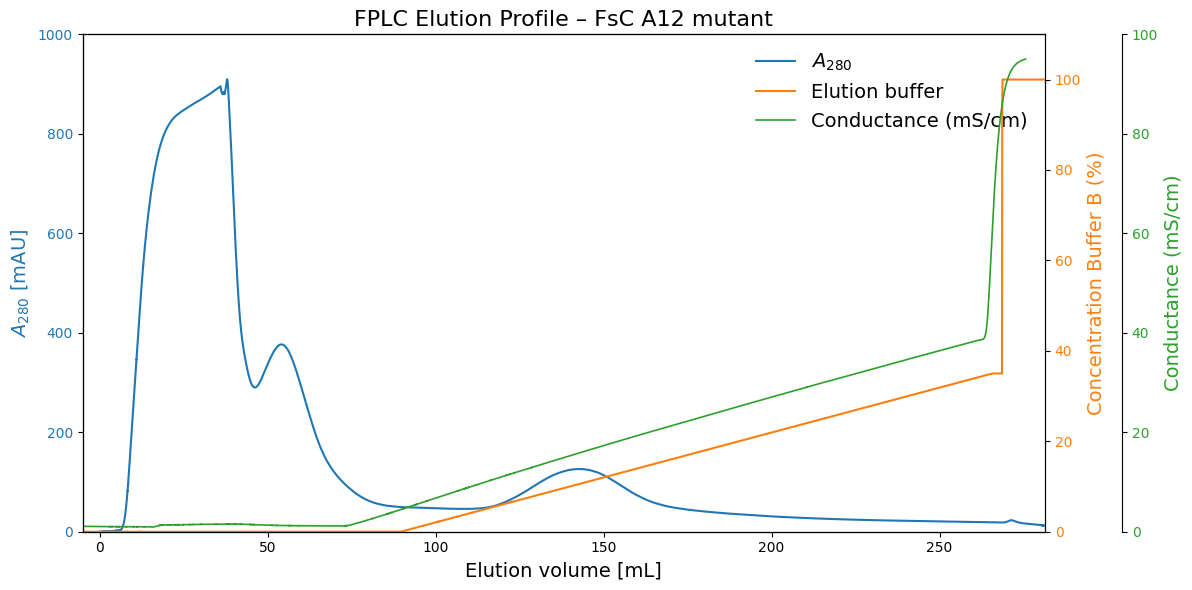

In [142]:
# Only for Big
base_filename = ('FsC A12 mutant')  # Extract base filename without extension ### Change for each !!!!

df = df_big

# Create figure and axis
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))  
fs = 14  # Font size

# Plot UV 280
axs.plot(df['ml'], df['mAU'], color='tab:blue', label='$A_{280}$')  
axs.set_ylabel('$A_{280}$ [mAU]', fontsize=fs, color='tab:blue')
axs.tick_params(axis='y', labelcolor='tab:blue')

# Plot Elution buffer
axs02 = axs.twinx()
axs02.plot(df['%_ml'], df['%'], color='tab:orange', label='Elution buffer')
axs02.set_ylabel('Concentration Buffer B (%)', fontsize=fs, color='tab:orange')
axs02.tick_params(axis='y', labelcolor='tab:orange')
axs02.set_ylim(0, 110)

# Plot Conductivity
axs03 = axs.twinx()
axs03.spines["right"].set_position(("axes", 1.08))
axs03.plot(df['ml'] * 2.152 * 1, df['mS/cm'], color='tab:green', label='Conductance (mS/cm)', linewidth=1.2) #shifts the axis if nessesary by multiplying with 2.152 
axs03.set_ylabel('Conductance (mS/cm)', fontsize=fs, color='tab:green')
axs03.tick_params(axis='y', labelcolor='tab:green')
axs03.set_ylim(0, 100)

 #Mark fractions
#for i, j in zip(df['frac_ml'].dropna(), df['frac'].dropna()):
    #if "Waste" not in j: #only eery 5th label
        #axs.vlines(i, 0, 20, color='k', linestyle='--', alpha=0.6)
        #axs.text(i - 0.5, 22, j, rotation=45, fontsize=8)

#label every 5th fraction only
frac_ml = df['frac_ml'].dropna().tolist()
frac = df['frac'].dropna().tolist()
 
#for idx, (i, j) in enumerate(zip(frac_ml, frac)):
#    if "Waste" not in j and idx % 300 == 0:  #Only every 5th label
#        axs.text(i - 0.5, 45, j, rotation=45, fontsize=8)

# Legend: Combine handles from all axes
lines1, labels1 = axs.get_legend_handles_labels()
lines2, labels2 = axs02.get_legend_handles_labels()
lines3, labels3 = axs03.get_legend_handles_labels()

axs.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc='upper right',
    fontsize=fs,
    frameon=False
)

# Axis settings
axs.set_xlabel('Elution volume [mL]', fontsize=fs)
axs.set_ylim(0, 1000)
axs.set_xlim(-5, df['ml'].max())  

axs.set_title(f'FPLC Elution Profile – {base_filename}', fontsize=fs + 2)
fig.tight_layout()
plt.show()

plt.show(block=True)

In [ ]:
# Plot just a part of the graph: 



# Fix: keep fraction labels as text
df['frac'] = df['frac'].astype(str)

# Create figure and axis
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))  
fs = 14  # Font size

# Plot UV 280
axs.plot(df['ml'], df['mAU'], color='tab:blue', label='$A_{280}$')  
axs.set_ylabel('$A_{280}$ [mAU]', fontsize=fs, color='tab:blue')
axs.tick_params(axis='y', labelcolor='tab:blue')

# Plot Elution buffer
axs02 = axs.twinx()
axs02.plot(df['%_ml'], df['%'], color='tab:orange', label='Elution buffer')
axs02.set_ylabel('Concentration Buffer B (%)', fontsize=fs, color='tab:orange')
axs02.tick_params(axis='y', labelcolor='tab:orange')
axs02.set_ylim(0, 110)

# Plot Conductivity
axs03 = axs.twinx()
axs03.spines["right"].set_position(("axes", 1.08))
axs03.plot(df['ml']*2.152, df['mS/cm'], color='tab:green', label='Conductance (mS/cm)', linewidth=1.2)
axs03.set_ylabel('Conductance (mS/cm)', fontsize=fs, color='tab:green')
axs03.tick_params(axis='y', labelcolor='tab:green')
axs03.set_ylim(0, 90)

# Mark fractions
for i, j in zip(df['frac_ml'].dropna(), df['frac'].dropna()):      
    if 100 <= i <= 180 and "Waste" not in j:        ##### change here !!!!
        axs.vlines(i, 0, 43, color='k', linestyle='--', alpha=0.6)
        axs.text(i - 0.5, 45, j, rotation=45, fontsize=8)

# Legend: Combine handles from all axes
lines1, labels1 = axs.get_legend_handles_labels()
lines2, labels2 = axs02.get_legend_handles_labels()
lines3, labels3 = axs03.get_legend_handles_labels()

axs.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc='upper right',
    fontsize=fs,
    frameon=False
)

# Axis settings
axs.set_xlabel('Elution volume [mL]', fontsize=fs)
axs.set_ylim(0, 150)    # change here !!!!!
axs.set_xlim(100, 180)    # Change here !!!!

axs.set_title(f'FPLC Elution Profile – {L182A_wat}', fontsize=fs + 2)
fig.tight_layout()
plt.show()